# 00 — Diagnóstico y comprensión de datos (Fase 1 / Ruta C)

**Objetivo:** conectarse en vivo al MySQL CDR de Asterisk y al índice del
filesystem de grabaciones para replicar las consultas E1–E6, generar figuras y
exportar las **Tablas 1 y 2** del capítulo académico, cerrando la Fase 1 con
evidencia reproducible.

> Todo corre dentro del contenedor `uisrael_diagnostico`. Las credenciales se
> leen de `.env` (nunca embebidas en el notebook). Acceso al CDR **solo lectura**.

Para exportar a `.ipynb` (entregable del capítulo):
```bash
jupytext --to notebook notebooks/00_diagnostico.py
```

In [1]:
import os
import gzip
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

load_dotenv()  # lee /work/.env montado (o variables del env_file de compose)

OUT_DIR = Path(os.getenv("OUT_DIR", "/work/data/diag"))
FIG_DIR = OUT_DIR / "figuras"
TAB_DIR = OUT_DIR / "tablas"
for d in (OUT_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

CDR_TABLE = os.getenv("CDR_TABLE", "cdr")
print("Salidas ->", OUT_DIR)

Salidas -> /work/data/diag


In [2]:
def get_engine():
    """Motor SQLAlchemy de SOLO LECTURA al CDR de Asterisk (latin1 -> UTF-8)."""
    user = os.environ["CDR_USER"]
    pwd = os.environ["CDR_PASSWORD"]
    host = os.environ["CDR_HOST"]
    port = os.getenv("CDR_PORT", "3306")
    db = os.environ["CDR_DB"]
    charset = os.getenv("CDR_CHARSET", "latin1")
    url = f"mysql+pymysql://{user}:{pwd}@{host}:{port}/{db}?charset={charset}"
    return create_engine(url, pool_pre_ping=True)


engine = get_engine()

# Sanidad: ¿conecta y cuántas columnas tiene el CDR?
with engine.connect() as c:
    cols = pd.read_sql(text(f"SHOW COLUMNS FROM {CDR_TABLE}"), c)
print(f"Conexión OK. Columnas en `{CDR_TABLE}`:")
cols

Conexión OK. Columnas en `cdr`:


,Field,Type,Null,Key,Default,Extra
0,calldate,datetime,NO,MUL,0000-00-00 00:00:00,
1,clid,varchar(80),NO,,,
2,src,varchar(80),NO,MUL,,
3,dst,varchar(80),NO,MUL,,
4,dcontext,varchar(80),NO,,,
5,channel,varchar(80),NO,,,
6,dstchannel,varchar(80),NO,,,
7,lastapp,varchar(80),NO,,,
8,lastdata,varchar(80),NO,,,
9,duration,int(11),NO,,0,


## E1 — Volúmenes por año y `disposition`
Confirma el universo real (~24,76 M CDR) y la distribución de resultados.

In [3]:
q_e1 = text(f"""
    SELECT YEAR(calldate) AS anio, disposition, COUNT(*) AS n
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY YEAR(calldate), disposition
    ORDER BY anio, disposition
""")
e1 = pd.read_sql(q_e1, engine)
piv_e1 = e1.pivot_table(index="anio", columns="disposition", values="n",
                        aggfunc="sum", fill_value=0)
piv_e1["TOTAL"] = piv_e1.sum(axis=1)
piv_e1

disposition,ANSWERED,BUSY,FAILED,NO ANSWER,TOTAL
anio,,,,,
2018,723196,27877,21572,453472,1226117
2019,3142736,200670,180379,2270367,5794152
2020,1500807,91854,14694,925740,2533095
2021,1529876,99464,13455,1056735,2699530
2022,1369154,48313,9998,1092204,2519669
2023,1397816,57156,13602,1238230,2706804
2024,1387265,111250,26089,1519740,3044344
2025,1268883,100208,20253,1212950,2602294
2026,553960,73058,3740,458390,1089148


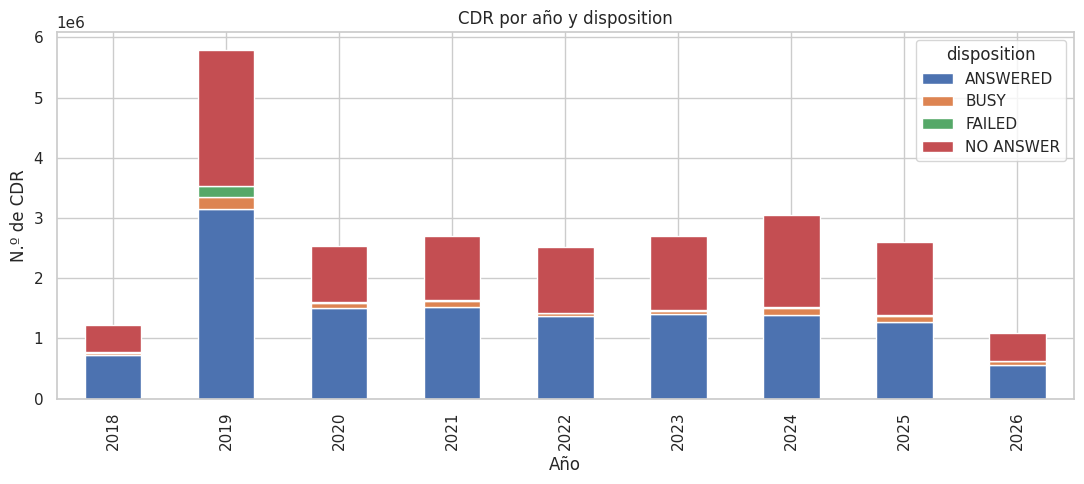

In [4]:
ax = piv_e1.drop(columns="TOTAL").plot(kind="bar", stacked=True, figsize=(11, 5))
ax.set_title("CDR por año y disposition")
ax.set_xlabel("Año"); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e1_cdr_por_anio.png", dpi=150); plt.show()

## E2 — Registros corruptos (`calldate = '0000-00-00'`)
Esperado ≈ 2,25 %, coincidentes con `src`/`disposition` vacíos → descartar en Bronce.

In [5]:
q_e2 = text(f"""
    SELECT
      COUNT(*) AS total,
      SUM(calldate = '0000-00-00 00:00:00') AS corruptos,
      SUM(calldate = '0000-00-00 00:00:00' AND (src = '' OR src IS NULL)) AS corr_src_vacio,
      SUM(calldate = '0000-00-00 00:00:00' AND (disposition = '' OR disposition IS NULL)) AS corr_disp_vacio
    FROM {CDR_TABLE}
""")
e2 = pd.read_sql(q_e2, engine)
e2["pct_corruptos"] = 100 * e2["corruptos"] / e2["total"]
e2

,total,corruptos,corr_src_vacio,corr_disp_vacio,pct_corruptos
0,24773174,"558,021.00","558,021.00","558,021.00",2.25


## E3 — Tasa de llenado del IVR (`pregunta1/2/3`)
Esperado < 0,001 % → **descartado** como señal analítica. (Se salta si las columnas no existen.)

In [6]:
col_names = set(cols["Field"].str.lower())
if {"pregunta1", "pregunta2", "pregunta3"} & col_names:
    q_e3 = text(f"""
        SELECT
          COUNT(*) AS total,
          SUM(pregunta1 IS NOT NULL AND pregunta1 <> '') AS p1,
          SUM(pregunta2 IS NOT NULL AND pregunta2 <> '') AS p2,
          SUM(pregunta3 IS NOT NULL AND pregunta3 <> '') AS p3
        FROM {CDR_TABLE}
    """)
    e3 = pd.read_sql(q_e3, engine)
    display(e3)
else:
    print("Sin columnas pregunta1/2/3 en este esquema — nada que evaluar.")

,total,p1,p2,p3
0,24773174,31.00,31.00,2.00


## E4 — Utilización de `urlrecord`
Esperado ≈ 0,13 % → el enlace por reconstrucción del filesystem es el camino PRINCIPAL.

In [7]:
if "urlrecord" in col_names:
    q_e4 = text(f"""
        SELECT COUNT(*) AS total,
               SUM(urlrecord IS NOT NULL AND urlrecord <> '') AS con_url
        FROM {CDR_TABLE}
    """)
    e4 = pd.read_sql(q_e4, engine)
    e4["pct_con_url"] = 100 * e4["con_url"] / e4["total"]
    display(e4)
else:
    print("Sin columna urlrecord en este esquema.")

,total,con_url,pct_con_url
0,24773174,"33,055.00",0.13


## E5 — Contactabilidad, duración/billsec e interanual
Contactabilidad global ≈ 53 %; caída interanual 2020→2024 (efecto TrueCaller);
outliers de `duration` por `hangup` fallido (máx ≈ 86 días).

In [8]:
q_e5_global = text(f"""
    SELECT
      COUNT(*) AS validos,
      SUM(disposition = 'ANSWERED') AS answered,
      AVG(CASE WHEN disposition='ANSWERED' THEN duration END) AS dur_media,
      MAX(CASE WHEN disposition='ANSWERED' THEN duration END) AS dur_max,
      AVG(CASE WHEN disposition='ANSWERED' THEN billsec  END) AS billsec_media
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
""")
e5g = pd.read_sql(q_e5_global, engine)
e5g["contactabilidad_pct"] = 100 * e5g["answered"] / e5g["validos"]
e5g

,validos,answered,dur_media,dur_max,billsec_media,contactabilidad_pct
0,24215153,"12,873,693.00",59.90,7441536,52.46,53.16


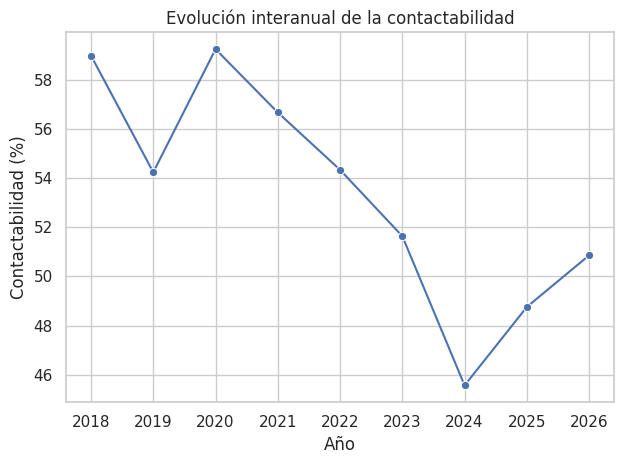

,anio,validos,answered,contactabilidad_pct
0,2018,1226117,"723,196.00",58.98
1,2019,5794152,"3,142,736.00",54.24
2,2020,2533095,"1,500,807.00",59.25
3,2021,2699530,"1,529,876.00",56.67
4,2022,2519669,"1,369,154.00",54.34
5,2023,2706804,"1,397,816.00",51.64
6,2024,3044344,"1,387,265.00",45.57
7,2025,2602294,"1,268,883.00",48.76
8,2026,1089148,"553,960.00",50.86


In [9]:
q_e5_anual = text(f"""
    SELECT YEAR(calldate) AS anio,
           COUNT(*) AS validos,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY YEAR(calldate) ORDER BY anio
""")
e5a = pd.read_sql(q_e5_anual, engine)
e5a["contactabilidad_pct"] = 100 * e5a["answered"] / e5a["validos"]

ax = sns.lineplot(data=e5a, x="anio", y="contactabilidad_pct", marker="o")
ax.set_title("Evolución interanual de la contactabilidad")
ax.set_xlabel("Año"); ax.set_ylabel("Contactabilidad (%)")
plt.tight_layout(); plt.savefig(FIG_DIR / "e5_contactabilidad_anual.png", dpi=150); plt.show()
e5a

## E6 — Top 20 agentes (`src`), distribución por hora y por día de la semana

In [10]:
q_top = text(f"""
    SELECT src, COUNT(*) AS n
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY src ORDER BY n DESC LIMIT 20
""")
top_src = pd.read_sql(q_top, engine)
top_src

,src,n
0,964256639,762313
1,23815940,753041
2,963150315,631047
3,963166652,630141
4,963161268,630110
5,963161474,629807
6,963155909,629709
7,963155676,629562
8,963155716,629012
9,963161019,625535


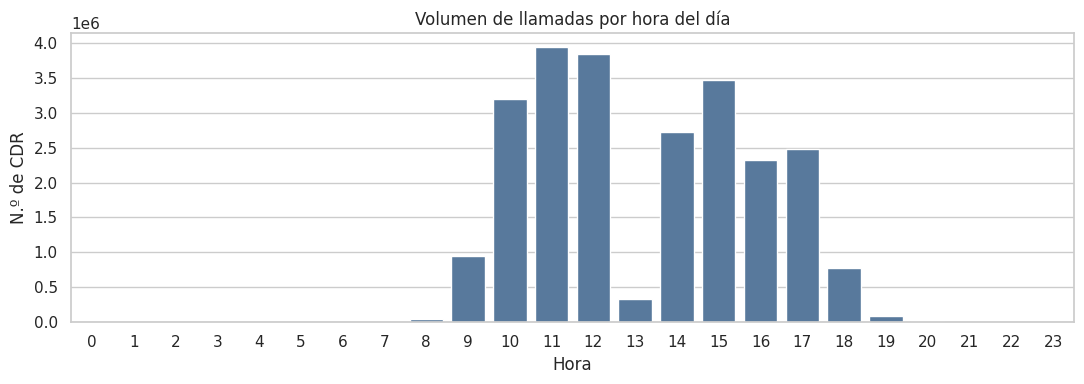

In [11]:
q_hora = text(f"""
    SELECT HOUR(calldate) AS hora,
           COUNT(*) AS n,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY HOUR(calldate) ORDER BY hora
""")
por_hora = pd.read_sql(q_hora, engine)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=por_hora, x="hora", y="n", ax=ax, color="#4C78A8")
ax.set_title("Volumen de llamadas por hora del día")
ax.set_xlabel("Hora"); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e6_por_hora.png", dpi=150); plt.show()

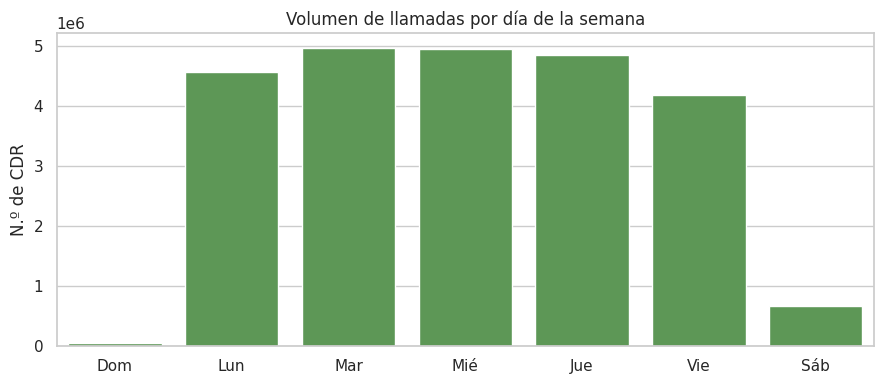

,dow,n,answered,dia
0,1,39071,"19,383.00",Dom
1,2,4557388,"2,443,172.00",Lun
2,3,4968514,"2,637,578.00",Mar
3,4,4943319,"2,636,511.00",Mié
4,5,4855050,"2,563,421.00",Jue
5,6,4183770,"2,223,740.00",Vie
6,7,668041,"349,888.00",Sáb


In [12]:
q_dow = text(f"""
    SELECT DAYOFWEEK(calldate) AS dow,
           COUNT(*) AS n,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY DAYOFWEEK(calldate) ORDER BY dow
""")
por_dia = pd.read_sql(q_dow, engine)
dias = {1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
por_dia["dia"] = por_dia["dow"].map(dias)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=por_dia, x="dia", y="n", ax=ax, color="#54A24B")
ax.set_title("Volumen de llamadas por día de la semana")
ax.set_xlabel(""); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e6_por_dia.png", dpi=150); plt.show()
por_dia

## Audio — Caracterización del alcance (call center de ventas: ext. 200–299, OUT)

Requiere `data/diag/audio_index.tsv.gz` (generado por `scripts/diagnostico_audio.sh`
en el servidor Asterisk, SOLO LECTURA, y descargado con `scp`).

**Alcance del proyecto (decisión del tesista):** solo las **llamadas salientes** de los
agentes de ventas → carpetas `2xx/OUT` con `2xx` = extensión **200–299**. Se excluyen
obligatoriamente la subcarpeta `INPUT` (entrantes → trabajo futuro), otros departamentos
(300–399, 400–499) y carpetas de proyectos/pruebas/campañas (`PREDICTIVO`,
`CLINICA_DE_VENTAS`, etc.), aunque contengan extensiones 2xx en el nombre.
Nombre en ventas: `{YYYYMMDDHHmmss}-{extensión}-{teléfono_cliente}` (100 % del periodo).

ALCANCE 200–299 / OUT: 7,061,447 grabaciones | 424.2 GB | 100 agentes


,métrica,valor
0,Grabaciones (alcance 200–299 / OUT),"7,061,447.00"
1,.mp3,"7,013,029.00"
2,.wav (sin convertir),"48,418.00"
3,Tamaño total (GB),424.20
4,Agentes (extensiones 2xx),100.00


,anio,archivos,GB
0,2018,569351,68.10
1,2019,407529,50.00
2,2020,331679,24.90
3,2021,333105,28.50
4,2022,196748,19.10
5,2023,981354,52.80
6,2024,1901628,86.90
7,2025,1637812,64.70
8,2026,702241,29.10


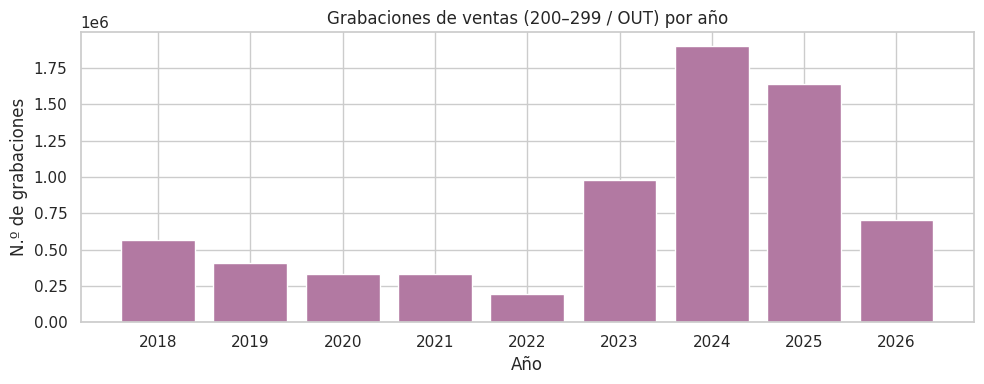

,extension,grabaciones
0,234,222093
1,204,193598
2,226,170369
3,222,163769
4,203,153255
5,220,152686
6,213,151562
7,227,150372
8,201,141145
9,216,139625


In [13]:
import re

AUDIO_INDEX = Path(os.getenv("AUDIO_INDEX", "/work/data/diag/audio_index.tsv.gz"))
AUDIO_ROOT_REL = os.getenv("AUDIO_ROOT", "/home/grabacion/monitor/111111111111").rstrip("/") + "/"
RX_EXT = re.compile(r"^2\d\d$")      # carpeta L1 = extensión 200–299 EXACTA
RX_TS = re.compile(r"^(\d{14})")     # timestamp YYYYMMDDHHmmss al inicio del nombre


def scope_row(rel):
    """Devuelve (ext, telefono, ts, bytes_ok) si `rel` está en el alcance 2xx/OUT, si no None."""
    segs = rel.split("/")
    if len(segs) < 3 or not RX_EXT.match(segs[0]) or segs[1] != "OUT":
        return None
    base = re.sub(r"\.(mp3|wav)$", "", segs[-1], flags=re.I)
    if not RX_TS.match(base):
        return None
    flds = base.split("-")
    tel = "-".join(flds[2:]) if len(flds) >= 3 else ""
    return (segs[0], tel, base[:14])


if AUDIO_INDEX.exists():
    n_files = 0
    tot_bytes = 0
    ext_mp3 = 0
    ext_wav = 0
    by_year = {}
    by_year_bytes = {}
    by_ext = {}
    with gzip.open(AUDIO_INDEX, "rt", encoding="utf-8", errors="replace") as fh:
        for ln in fh:
            cols_ln = ln.rstrip("\n").split("\t")
            path = cols_ln[0]
            try:
                size = int(cols_ln[1])
            except (IndexError, ValueError):
                size = 0
            rel = path[len(AUDIO_ROOT_REL):] if path.startswith(AUDIO_ROOT_REL) else path
            r = scope_row(rel)
            if r is None:
                continue
            ext_dir, _tel, ts = r
            n_files += 1
            tot_bytes += size
            yr = ts[:4]
            by_year[yr] = by_year.get(yr, 0) + 1
            by_year_bytes[yr] = by_year_bytes.get(yr, 0) + size
            by_ext[ext_dir] = by_ext.get(ext_dir, 0) + 1
            if path.lower().endswith(".wav"):
                ext_wav += 1
            else:
                ext_mp3 += 1

    resumen_audio = pd.DataFrame({
        "métrica": [
            "Grabaciones (alcance 200–299 / OUT)", "  .mp3", "  .wav (sin convertir)",
            "Tamaño total (GB)", "Agentes (extensiones 2xx)",
        ],
        "valor": [
            n_files, ext_mp3, ext_wav,
            round(tot_bytes / 1024**3, 1), len(by_ext),
        ],
    })
    print(f"ALCANCE 200–299 / OUT: {n_files:,} grabaciones | "
          f"{tot_bytes/1024**3:.1f} GB | {len(by_ext)} agentes")
    display(resumen_audio)

    audio_anual = pd.DataFrame(sorted(by_year.items()), columns=["anio", "archivos"])
    audio_anual["GB"] = [round(by_year_bytes[y] / 1024**3, 1) for y in audio_anual["anio"]]
    display(audio_anual)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(audio_anual["anio"], audio_anual["archivos"], color="#B279A2")
    ax.set_title("Grabaciones de ventas (200–299 / OUT) por año")
    ax.set_xlabel("Año"); ax.set_ylabel("N.º de grabaciones")
    plt.tight_layout(); plt.savefig(FIG_DIR / "audio_ventas_por_anio.png", dpi=150); plt.show()

    audio_top_ext = (pd.DataFrame(sorted(by_ext.items(), key=lambda kv: -kv[1]),
                                  columns=["extension", "grabaciones"]).head(20))
    display(audio_top_ext)
    resumen_audio.to_csv(TAB_DIR / "tabla_audio_resumen.csv", index=False)
    audio_disponible = True
else:
    print(f"Falta {AUDIO_INDEX}. Corre scripts/diagnostico_audio.sh en el servidor")
    print("y descárgalo:  scp USER@IP_ASTERISK:/tmp/diag/audio_index.tsv.gz ./data/diag/")
    audio_disponible = False

## Cruce CDR ↔ grabación (ventas OUT) — tasa de emparejamiento

**Método (record linkage, ref. Christen 2012):** llave compuesta con tolerancia temporal

> audio(`ext`, `teléfono`, `ts`) ↔ CDR(`ext`∈`channel`/`dstchannel`, `dst`=`teléfono`,
> `|calldate − ts| ≤ TOL`, vecino más cercano)

Claves del hallazgo: el `src` del CDR es el caller-ID del **troncal** (no el agente);
la extensión del agente vive en `channel`/`dstchannel` (`SIP/2xx-...`). El `uniqueid`
**no** está embebido en las grabaciones de ventas. Umbral de gobernanza: cobertura ≥ 95 %.
Parametrizado por rango (un mes representativo) para que sea tratable en la laptop.

In [14]:
FECHA_DESDE = "2025-05-01"
FECHA_HASTA = "2025-05-31"
TOL_SEG = 180


def cdr_ext(s):
    """Extrae la extensión 2xx del agente desde channel/dstchannel (p. ej. SIP/228-...)."""
    m = re.search(r"(?<!\d)(2\d\d)(?!\d)", str(s))
    return m.group(1) if m else None


if audio_disponible:
    d0, d1 = FECHA_DESDE.replace("-", ""), FECHA_HASTA.replace("-", "")
    filas = []
    with gzip.open(AUDIO_INDEX, "rt", encoding="utf-8", errors="replace") as fh:
        for ln in fh:
            path = ln.split("\t", 1)[0]
            rel = path[len(AUDIO_ROOT_REL):] if path.startswith(AUDIO_ROOT_REL) else path
            r = scope_row(rel)
            if r is None:
                continue
            ext_dir, tel, ts = r
            if d0 <= ts[:8] <= d1 and tel:
                filas.append((ts, ext_dir, tel))
    aud = pd.DataFrame(filas, columns=["ts", "ext", "phone"])
    aud["dt"] = pd.to_datetime(aud["ts"], format="%Y%m%d%H%M%S", errors="coerce")
    print(f"Grabaciones ventas OUT {FECHA_DESDE}..{FECHA_HASTA}: {len(aud):,}  "
          f"(agentes: {aud['ext'].nunique()}, contactos: {aud['phone'].nunique():,})")

    q_cdr = text(f"""
        SELECT calldate, dst, channel, dstchannel
        FROM {CDR_TABLE}
        WHERE calldate >= :d AND calldate < :h
    """)
    cdr = pd.read_sql(q_cdr, engine,
                      params={"d": FECHA_DESDE + " 00:00:00", "h": FECHA_HASTA + " 23:59:59"})
    cdr["ext_any"] = cdr["channel"].map(cdr_ext).fillna(cdr["dstchannel"].map(cdr_ext))
    cdr["dt"] = pd.to_datetime(cdr["calldate"], errors="coerce")

    # índice (ext, teléfono) -> lista de tiempos de llamada
    idx = {}
    par = cdr.dropna(subset=["ext_any"])
    for e, dd, t in zip(par["ext_any"], par["dst"].astype(str), par["dt"]):
        idx.setdefault((e, dd), []).append(t)

    def match_key(row):
        return (row["ext"], row["phone"]) in idx

    def match_win(row, tol=TOL_SEG):
        lst = idx.get((row["ext"], row["phone"]))
        return bool(lst) and (not pd.isna(row["dt"])) and \
            any(abs((row["dt"] - t).total_seconds()) <= tol for t in lst)

    m_key = aud.apply(match_key, axis=1)
    m_win = aud.apply(match_win, axis=1)
    cob_key = 100 * m_key.mean() if len(aud) else float("nan")
    cob_win = 100 * m_win.mean() if len(aud) else float("nan")

    cruce_resumen = pd.DataFrame({
        "métrica": [
            "Grabaciones en el rango",
            "Cobertura (ext + teléfono)",
            f"Cobertura (ext + teléfono + |t|≤{TOL_SEG}s)",
            "Huérfanas (sin CDR emparejado)",
        ],
        "valor": [
            f"{len(aud):,}",
            f"{cob_key:.2f} %",
            f"{cob_win:.2f} %",
            f"{(~m_win).sum():,}",
        ],
    })
    display(cruce_resumen)
    print(f"Umbral de gobernanza (cobertura ≥ 95 %): "
          f"{'CUMPLE' if cob_win >= 95 else 'NO CUMPLE'}")

    # KPI de intentos/reintentos por contacto (cada grabación = un intento del asesor)
    intentos = aud.groupby(["ext", "phone"]).size().rename("intentos").reset_index()
    dist_intentos = (intentos["intentos"].value_counts().sort_index()
                     .rename_axis("intentos_por_contacto").reset_index(name="n_contactos"))
    print(f"\nContactos únicos (ext, teléfono): {len(intentos):,} | "
          f"intentos medios/contacto: {intentos['intentos'].mean():.2f} | "
          f"máx: {intentos['intentos'].max()}")
    display(dist_intentos.head(12))
else:
    aud = None
    cruce_resumen = None
    print("Sin índice de audio: no se puede calcular el cruce todavía.")

Grabaciones ventas OUT 2025-05-01..2025-05-31: 153,533  (agentes: 36, contactos: 37,787)


,métrica,valor
0,Grabaciones en el rango,"153,533"
1,Cobertura (ext + teléfono),100.00 %
2,Cobertura (ext + teléfono + |t|≤180s),100.00 %
3,Huérfanas (sin CDR emparejado),0


Umbral de gobernanza (cobertura ≥ 95 %): CUMPLE

Contactos únicos (ext, teléfono): 45,805 | intentos medios/contacto: 3.35 | máx: 260


,intentos_por_contacto,n_contactos
0,1,16745
1,2,10293
2,3,5800
3,4,3827
4,5,2302
5,6,1577
6,7,1138
7,8,842
8,9,634
9,10,489


## Exportación de Tablas (capítulo académico)

In [15]:
with pd.ExcelWriter(TAB_DIR / "tablas_diagnostico.xlsx") as xl:
    piv_e1.to_excel(xl, sheet_name="E1_por_anio")
    e2.to_excel(xl, sheet_name="E2_corruptos", index=False)
    e5g.to_excel(xl, sheet_name="E5_global", index=False)
    e5a.to_excel(xl, sheet_name="E5_anual", index=False)
    top_src.to_excel(xl, sheet_name="E6_top_agentes", index=False)
    por_hora.to_excel(xl, sheet_name="E6_por_hora", index=False)
    por_dia.to_excel(xl, sheet_name="E6_por_dia", index=False)
    if audio_disponible:
        resumen_audio.to_excel(xl, sheet_name="Audio_resumen", index=False)
        audio_anual.to_excel(xl, sheet_name="Audio_por_anio", index=False)
        audio_top_ext.to_excel(xl, sheet_name="Audio_top_agentes", index=False)
    if cruce_resumen is not None:
        cruce_resumen.to_excel(xl, sheet_name="Cruce_cobertura", index=False)
print("Tablas exportadas a", TAB_DIR / "tablas_diagnostico.xlsx")

Tablas exportadas a /work/data/diag/tablas/tablas_diagnostico.xlsx
